# Занятие 8: Рекомендательные системы

## 1. Что такое рекомендательные системы

Рекомендательные системы — это модели, которые предсказывают, 
что именно понравится пользователю.

Примеры:
- Netflix → “Потому что вам понравилось Interstellar”
- YouTube → “Вам может понравиться этот ролик”
- Spotify → «Daily Mix» + “Ваше персональное радио”
- Amazon → “Люди, купившие это, купили и…”
- Steam → “Игры, похожие на ваши”

**Цель: угадать предпочтения пользователя.**

## 2. Какие существуют подходы?

Два больших семейства:

1. Content-based (по содержанию)

2. Collaborative Filtering (коллаборативная фильтрация)

![Content-based vs Collaborative Filtering](../materials/imgs/Content-based_vs_Collaborative_Filtering.png)

## 3. Content-based рекомендации

> “Порекомендовать то, что похоже на то, что тебе уже понравилось”

**Идея:**

Каждый фильм — это набор признаков:

|Признак|	Значение|
|:------|:---------------------|
|Жанры|	Action, Sci-Fi|
|Актеры|	DiCaprio, Tom Hardy|
|Режиссёр|	Christopher Nolan|
|Описание| “A thief… dreams…”|
|Ключевые слова|	dream, heist, subconscious|

Мы можем представить фильм как вектор признаков, например:

**Фильм → вектор длиной 3000**

```
[0, 1, 0, 0, 1, ...]
```

И ищем похожесть фильмов — например, по косинусному расстоянию.

**Контент-бейзд подходит когда:**

- У нас много информации о фильмах (жанры, описание)

- Мало данных о пользователях

- Новые фильмы появляются часто

**Примеры признаков для контентного подхода**

- TF-IDF по описанию фильма

- one-hot по жанрам

- эмбеддинги (BERT) по сюжету

- режиссёр, актёры

- теги пользователей

## 4. Collaborative Filtering (CF)

> “Порекомендовать то, что понравилось похожим пользователям”

**Главная идея:**

Если ты и другой пользователь **оцениваете одни и те же фильмы одинаково**,
значит — **вы похожи**.

И тогда:

> Если похожий на тебя пользователь любит “Interstellar”, то, возможно, понравится и тебе.

**Пример**
| Пользователь | Interstellar | Inception | Barbie | Gladiator |
| ------------ | ------------ | --------- | ------ | --------- |
| Ты           | ⭐⭐⭐⭐⭐        | ⭐⭐⭐⭐⭐     | ⭐      | ⭐⭐⭐⭐      |
| Вася         | ⭐⭐⭐⭐⭐        | ⭐⭐⭐⭐⭐     | ⭐      | ⭐⭐⭐⭐      |

*Вы похожи → Вася смотрит Dune → тебе рекомендуют Dune.*

### Два вида CF

### **4.1. User-Based CF**

Мы ищем похожих пользователей.

```
Ты →  [похожие пользователи] → фильмы, которые они оценили
```

### **4.2. Item-Based CF**

Мы ищем похожие фильмы по оценкам.

```
Interstellar → [похожие фильмы по оценкам других] 
```

*Пример:*

> Люди, которым нравится Interstellar, часто ставят высоко Inception → фильмы похожи.

## 5. Математика для обоих подходов

**Основная метрика похожести:**

Косинусная похожесть

```
sim(a, b) = (a · b) / (||a|| * ||b||)
```

Интерпретация:

- 1 → фильмы/пользователи максимально похожи

- 0 → абсолютно разные

- -1 → противоположные

## 6. Матрица “Пользователь × Фильм”

| userId | movieId | rating |
| ------ | ------- | ------ |
| 1      | 2571    | 5      |
| 1      | 32      | 3      |
| 2      | 2571    | 4      |
| 2      | 50      | 2      |

**Перегоняем в матрицу:**

| userId/movieId | 2571 | 32 | 50 | 2027 | ... |
| -------------- | ---- | -- | -- | ---- | --- |
| 1              | 5    | 3  | 0  | 0    | ... |
| 2              | 4    | 0  | 2  | 0    | ... |
| 3              | 0    | 5  | 0  | 3    | ... |

Где 0 = ещё не смотрел.

**Это база для:**

- User-based

- Item-based

- SVD

- Нейросетей

## 7. Проблема sparsity (разреженности)

Обычно пользователь смотрит < 1% всех фильмов. Поэтому таблица 98–99% пустая.

| 0 | 0 | 3 | 2 | 0 | 1 |
| - | - | - | - | - | - |
| 0 | 0 | 0 | 1 | 0 | 0 |
| 5 | 0 | 0 | 0 | 0 | 0 |
| 0 | 2 | 0 | 0 | 0 | 3 |
| 4 | 0 | 0 | 3 | 0 | 0 |

**Проблема:**

- считать похожесть трудно

- новые фильмы/пользователи → "cold start"

## 8. Cold Start Problem

**Новому пользователю нечего рекомендовать**

→ нет истории → нет вектора

*Решение:*

- попросить посмотреть 5 фильмов

- использовать контент-бейзд

**Новый фильм**

→ никто не оценил

*Решение:*

- использовать контентные признаки

## 9. Model-based CF

**Matrix Factorization, SVD**

Это уже “умные” модели, которые учатся скрытым признакам:

- Пользователь имеет вектор скрытых предпочтений

- Фильм имеет вектор скрытых особенностей

*И мы учим их так, чтобы:*

```
rating ≈ dot(user_vector, movie_vector)
```

**Пример:** 

Пользователь любит:

- космос +0.9

- драму +0.1

- экшен +0.6

А фильм “Interstellar” имеет:

- космос +1.0

- драма +0.1

- экшен +0.2

→ dot ~ высокая оценка.

## 10. Пример с SVD

![SVD](../materials/imgs/SVD.png)

```
Rating Matrix = U * Σ * Vᵀ
```

- U — матрица пользователей

- Vᵀ — матрица фильмов

- Σ — “важность” факторов

Это современная основа Netflix, YouTube и других систем (раньше).

## 11. Нейросети в рекомендациях

Современные системы используют:

- Autoencoders

- Embeddings пользователей/фильмов

- Two-tower модели

- Transformers

- Hybrid модели (CF + контент)

## 12. Сводка

| Метод         | Сильные стороны                     | Слабые                          |
| ------------- | ----------------------------------- | ------------------------------- |
| Content-based | работает с новыми фильмами, простая | не учитывает вкусы других людей |
| User-based CF | персонализированные советы          | плохо при sparse                |
| Item-based CF | стабильные советы                   | не учитывает стиль пользователя |
| SVD / модели  | мощные, защищены от sparsity        | требуют вычислительных ресурсов |

# Практическая часть

In [24]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse.linalg import svds

# скачиваем датасет
path = kagglehub.dataset_download("prajitdatta/movielens-100k-dataset")
DATA_DIR = os.path.join(path, "ml-100k")

print("Dataset folder:", DATA_DIR)
print(os.listdir(DATA_DIR))

Dataset folder: /home/danila/.cache/kagglehub/datasets/prajitdatta/movielens-100k-dataset/versions/1/ml-100k
['README', 'allbut.pl', 'mku.sh', 'u.data', 'u.genre', 'u.info', 'u.item', 'u.occupation', 'u.user', 'u1.base', 'u1.test', 'u2.base', 'u2.test', 'u3.base', 'u3.test', 'u4.base', 'u4.test', 'u5.base', 'u5.test', 'ua.base', 'ua.test', 'ub.base', 'ub.test']


## Загрузка данных

In [39]:
ratings_path = os.path.join(DATA_DIR, "u.data")
u_item_path = os.path.join(DATA_DIR, "u.item")
u_user_path = os.path.join(DATA_DIR, "u.user")

ratings = pd.read_csv(ratings_path, sep="\t", names=["userId","movieId","rating","timestamp"])
movie_cols = [
    "movieId","title","release_date","video_release_date","imdb_url",
    "unknown","Action","Adventure","Animation","Children","Comedy","Crime",
    "Documentary","Drama","Fantasy","FilmNoir","Horror","Musical","Mystery",
    "Romance","SciFi","Thriller","War","Western"
]
movies = pd.read_csv(u_item_path, sep="|", names=movie_cols, encoding="latin-1")

print(ratings.shape, movies.shape)
ratings.head()

(100000, 4) (1682, 24)


,userId,movieId,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


*Читаем u.data и u.item — необходимы для дальнейшей работы*

## Подготовка жанров (для TF-IDF)

In [40]:
genre_cols = movie_cols[5:]

def combine_genres(row):
    return " ".join([g for g in genre_cols if int(row[g]) == 1]) or "unknown"

movies['genres_str'] = movies.apply(combine_genres, axis=1)
movies['text_for_tfidf'] = movies['title'] + " " + movies['genres_str']

movies[['title','genres_str']].head()

,title,genres_str
0,Toy Story (1995),Animation Children Comedy
1,GoldenEye (1995),Action Adventure Thriller
2,Four Rooms (1995),Thriller
3,Get Shorty (1995),Action Comedy Drama
4,Copycat (1995),Crime Drama Thriller


*MovieLens 100k хранит жанры как 19 бинарных колонок → мы превращаем их в строку*

## Быстрый EDA

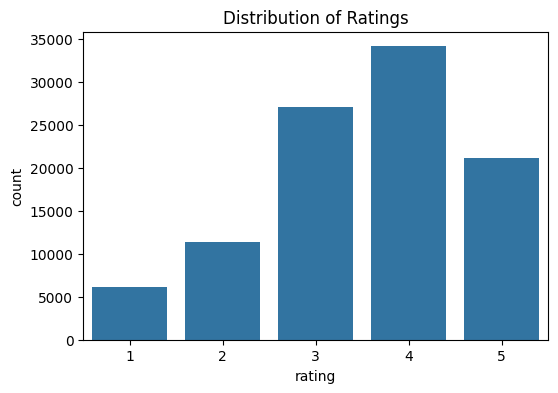

,movieId,0,title
0,50,583,Star Wars (1977)
1,258,509,Contact (1997)
2,100,508,Fargo (1996)
3,181,507,Return of the Jedi (1983)
4,294,485,Liar Liar (1997)
5,286,481,"English Patient, The (1996)"
6,288,478,Scream (1996)
7,1,452,Toy Story (1995)
8,300,431,Air Force One (1997)
9,121,429,Independence Day (ID4) (1996)


In [41]:
plt.figure(figsize=(6,4))
sns.countplot(x='rating', data=ratings)
plt.title("Distribution of Ratings")
plt.show()

top_movies = ratings.groupby('movieId').size().sort_values(ascending=False).head(10)
top_movies = top_movies.reset_index().merge(movies[['movieId','title']], on='movieId')
top_movies

*Распределение рейтингов и топ фильмов по популярности*

## 1. Content-based рекомендации

### 1.1 TF-IDF и косинусная похожесть

In [42]:
tfidf = TfidfVectorizer(stop_words='english', ngram_range=(1,2))
tfidf_matrix = tfidf.fit_transform(movies['text_for_tfidf'])

cosine_sim = cosine_similarity(tfidf_matrix)
title_to_idx = pd.Series(movies.index, index=movies['title']).drop_duplicates()

*Строим матрицу TF-IDF → считаем похожесть фильмов друг на друга*

### 1.2 Функция content-based рекомендаций

In [43]:
def recommend_content(title, n=10):
    idx = title_to_idx.get(title)
    if idx is None:
        print("Title not found")
        return
    
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:n+1]
    ids = [i for i,_ in sim_scores]

    recs = movies.iloc[ids][['movieId','title','genres_str']]
    recs['similarity'] = [s for _,s in sim_scores]
    return recs

recommend_content("Toy Story (1995)", 5)

,movieId,title,genres_str,similarity
1065,1066,Balto (1995),Animation Children,0.377700
1218,1219,"Goofy Movie, A (1995)",Animation Children Comedy Romance,0.373566
1469,1470,Gumby: The Movie (1995),Animation Children,0.321549
541,542,Pocahontas (1995),Animation Children Musical Romance,0.317434
1071,1072,"Pyromaniac's Love Story, A (1995)",Comedy Romance,0.301023


*Ищем похожие фильмы по жанрам и названию. Контентный подход*

## 2. Collaborative Filtering

### 2.1 User × Movie матрица

In [44]:
user_movie = ratings.pivot_table(index='userId', columns='movieId', values='rating')
user_movie_filled = user_movie.fillna(0)
user_movie.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
userId,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


*Матрица предпочтений*

### 2.2 User-based CF

In [45]:
user_sim = cosine_similarity(user_movie_filled)
user_sim_df = pd.DataFrame(user_sim, index=user_movie_filled.index, columns=user_movie_filled.index)

def recommend_user_based(user_id, n=10, k_neighbors=10):
    sim_scores = user_sim_df.loc[user_id].sort_values(ascending=False)
    neighbors = sim_scores.iloc[1:k_neighbors+1].index
    
    mean_scores = user_movie.loc[neighbors].mean(axis=0)
    seen = user_movie.loc[user_id].dropna().index

    recs = mean_scores[~mean_scores.index.isin(seen)].sort_values(ascending=False).head(n)
    return movies[movies['movieId'].isin(recs.index)][['movieId','title']].assign(score=recs.values)

recommend_user_based(1, 5)

,movieId,title,score
312,313,Titanic (1997),5.0
1006,1007,Waiting for Guffman (1996),5.0
1008,1009,Stealing Beauty (1996),5.0
1018,1019,"Die xue shuang xiong (Killer, The) (1989)",5.0
1167,1168,Little Buddha (1993),5.0


*Простая реализация user-based CF. Идея «похожие пользователи → предсказания»*

### 2.3 Item-based CF

In [46]:
movie_user = user_movie.T.fillna(0)
movie_sim = cosine_similarity(movie_user)
movie_sim_df = pd.DataFrame(movie_sim, index=movie_user.index, columns=movie_user.index)

def recommend_item_based(movie_id, n=10):
    sims = movie_sim_df[movie_id].sort_values(ascending=False)[1:n+1]
    return movies[movies['movieId'].isin(sims.index)][['movieId','title']].assign(score=sims.values)

recommend_item_based(1, 5)

,movieId,title,score
49,50,Star Wars (1977),0.734572
116,117,"Rock, The (1996)",0.699925
120,121,Independence Day (ID4) (1996),0.689786
180,181,Return of the Jedi (1983),0.664555
404,405,Mission: Impossible (1996),0.641322


*Быстрее, чем user-based, и обычно точнее*

## 3. Model-based (SVD)

### 3.1 SVD факторизация

In [47]:
R = user_movie.fillna(0).to_numpy()
user_mean = R.mean(axis=1)
R_demeaned = R - user_mean.reshape(-1,1)

U, sigma, Vt = svds(R_demeaned, k=50)
sigma_diag = np.diag(sigma)

pred_matrix = np.dot(np.dot(U, sigma_diag), Vt) + user_mean.reshape(-1,1)
preds_df = pd.DataFrame(pred_matrix, index=user_movie.index, columns=user_movie.columns)

*SVD — основа современных рекомендательных систем*

### 3.2 Рекомендации SVD

In [48]:
def recommend_svd(user_id, n=10):
    preds = preds_df.loc[user_id]
    seen = user_movie.loc[user_id].dropna().index
    
    recs = preds[~preds.index.isin(seen)].sort_values(ascending=False).head(n)
    return movies[movies['movieId'].isin(recs.index)][['movieId','title']].assign(score=recs.values)

recommend_svd(1, 5)

,movieId,title,score
356,357,One Flew Over the Cuckoo's Nest (1975),3.509642
384,385,True Lies (1994),3.097894
402,403,Batman (1989),2.971226
422,423,E.T. the Extra-Terrestrial (1982),2.752628
731,732,Dave (1993),2.605706


*Лучший подход из всех — факторизация скрытых предпочтений*

## 4. Гибридная система

### 4.1 Hybrid recommend()

In [49]:
def hybrid_recommend(user_id=None, title=None, n=7):
    print("=== Hybrid Recommendations ===\n")
    
    if title:
        print(">> Content-based:")
        display(recommend_content(title, n))
    
    if user_id:
        print("\n>> User-based CF:")
        display(recommend_user_based(user_id, n))
        
        print("\n>> SVD-based CF:")
        display(recommend_svd(user_id, n))

hybrid_recommend(user_id=1, title="Toy Story (1995)", n=5)

=== Hybrid Recommendations ===

>> Content-based:


,movieId,title,genres_str,similarity
1065,1066,Balto (1995),Animation Children,0.377700
1218,1219,"Goofy Movie, A (1995)",Animation Children Comedy Romance,0.373566
1469,1470,Gumby: The Movie (1995),Animation Children,0.321549
541,542,Pocahontas (1995),Animation Children Musical Romance,0.317434
1071,1072,"Pyromaniac's Love Story, A (1995)",Comedy Romance,0.301023



>> User-based CF:


,movieId,title,score
312,313,Titanic (1997),5.0
1006,1007,Waiting for Guffman (1996),5.0
1008,1009,Stealing Beauty (1996),5.0
1018,1019,"Die xue shuang xiong (Killer, The) (1989)",5.0
1167,1168,Little Buddha (1993),5.0



>> SVD-based CF:


,movieId,title,score
356,357,One Flew Over the Cuckoo's Nest (1975),3.509642
384,385,True Lies (1994),3.097894
402,403,Batman (1989),2.971226
422,423,E.T. the Extra-Terrestrial (1982),2.752628
731,732,Dave (1993),2.605706
